# ZDT4 Results

In [4]:
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_zdt4_front_true
from deap import benchmarks
from functools import partial
import matplotlib.pyplot as plt
import multiprocessing
# 1. Parâmetros (Substituindo as antigas variáveis globais)
IND_SIZE = 10
NPOP = 400
NGEN = 100
NOBJ = 2
NUM_TABLES = int((1 << NOBJ))
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1] * NOBJ

func_zdt4_segura = partial(benchmarks.zdt4)
toolbox = build_toolbox(func_zdt4_segura, IND_SIZE, NPOP, NOBJ)
pareto_real = generate_zdt4_front_true(10000, IND_SIZE)
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    reset = 1
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...
Evolução concluída!


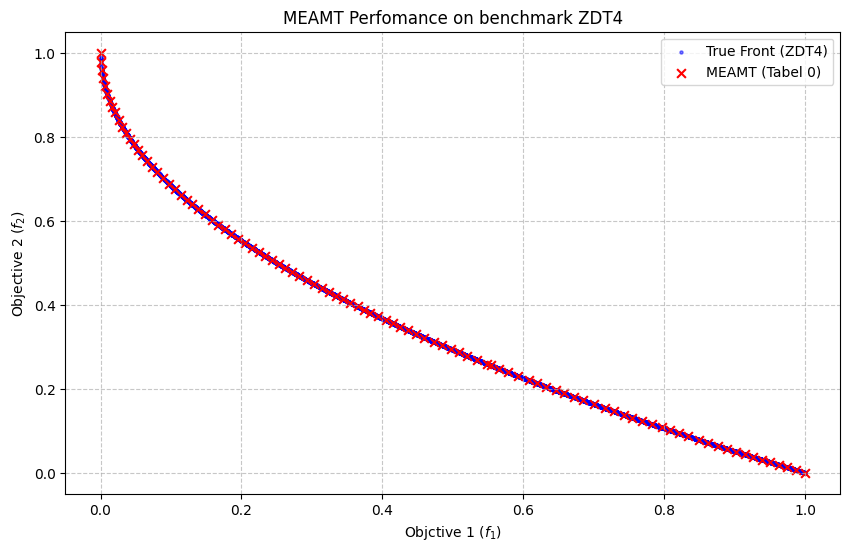

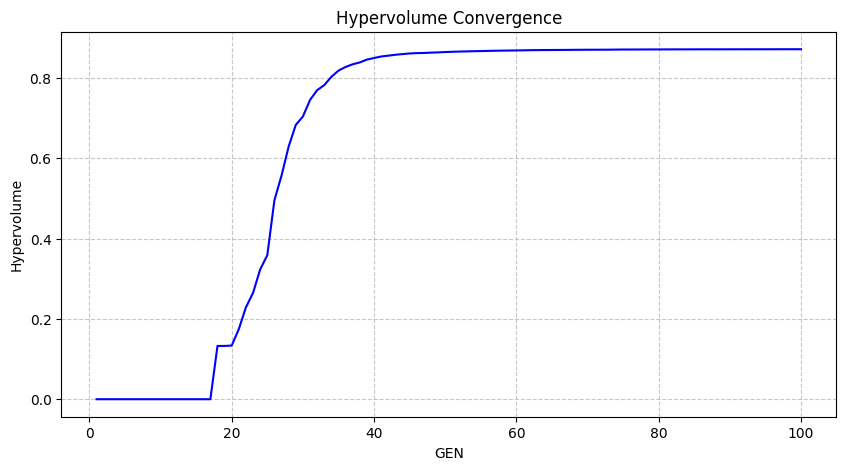

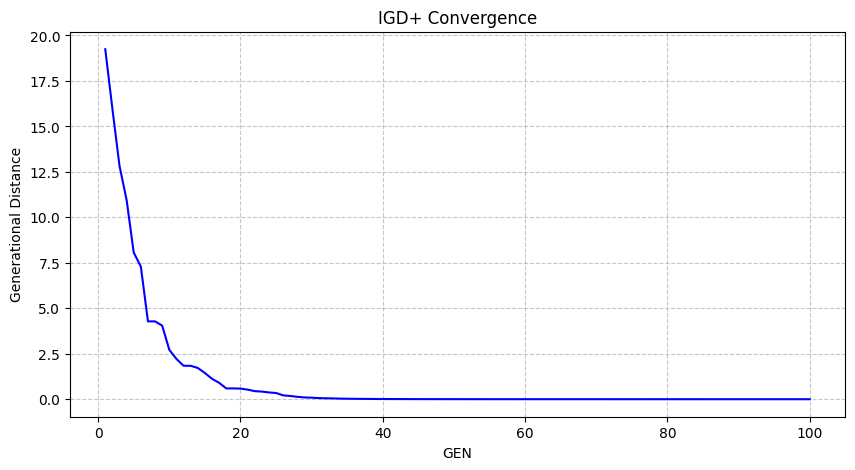

In [5]:
f1_approx = [ind.fitness.values[0] for ind in tabelas[0]]
f2_approx = [ind.fitness.values[1] for ind in tabelas[0]]

f1_true = [linha[0] for linha in pareto_real]
f2_true = [linha[1] for linha in pareto_real]


plt.figure(figsize=(10, 6))


plt.scatter(f1_true, f2_true, color='blue', s=5, alpha=0.5, label='True Front (ZDT4)')


plt.scatter(f1_approx, f2_approx, color='red', marker='x', s=40, label='MEAMT (Tabel 0)')

plt.title("MEAMT Perfomance on benchmark ZDT4")
plt.xlabel("Objctive 1 ($f_1$)")
plt.ylabel("Objective 2 ($f_2$)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Exibe o gráfico
plt.show()

# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()